🎯 Problema a Solucionar

El objetivo principal es construir un modelo de Regresión que pueda estimar con la mayor precisión posible el precio de venta (price) de un vehículo, dadas sus especificaciones.

⚙️ Definición del Problema (Business/Científico)

Pregunta de Negocio: ¿Cuánto debería costar un automóvil dadas sus características (tamaño del motor, potencia, tipo de combustible, estilo de carrocería, etc.)?

Tipo de Tarea de ML: Regresión. La variable objetivo (price) es continua.

Aplicaciones:

Determinación de Precios: Ayudar a concesionarios o vendedores a fijar un precio justo y competitivo para un vehículo nuevo o usado.

Evaluación de Características: Identificar qué características específicas (ej., tamaño del motor, tipo de tracción) tienen el mayor impacto en el precio final.

Análisis de Mercado: Entender cómo se valora un vehículo en el mercado en función de sus atributos.

🔑 Variable Objetivo y Características
Variable Objetivo (y): price (Precio del automóvil).

Características (X): Todas las demás columnas del dataset, como engine-size (tamaño del motor), horsepower (potencia), body-style (estilo de carrocería), fuel-type (tipo de combustible), etc.

In [ ]:
# Instalaciones (Generalmente no necesarias en Colab, pero se incluyen por si acaso)
!pip install pandas numpy scikit-learn matplotlib seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

2. Carga del Conjunto de Datos    

Nota: Debes descargar el archivo CSV desde la página de Kaggle (o cargarlo directamente a tu sesión de Colab) y nombrarlo Auto.csv.

In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets, model_selection, metrics



In [ ]:
# @title
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [ ]:
# @title
# Cargar el archivo CSV
try:
    df = pd.read_csv('Auto.csv')
    print("Datos cargados exitosamente.")
except FileNotFoundError:
    print("Error: El archivo '/content/drive/MyDrive/Liderando con la IA/Modulo1/Auto.csv' no se encuentra. Asegúrate de haberlo subido a tu Colab.")

# Inspección inicial de los datos
df.head()

Error: El archivo '/content/drive/MyDrive/Liderando con la IA/Modulo1/Auto.csv' no se encuentra. Asegúrate de haberlo subido a tu Colab.


NameError: name 'df' is not defined

3. Análisis Exploratorio de Datos (EDA)

Entendemos la estructura de los datos, identificamos tipos de variables, valores faltantes y realizamos una primera exploración visual.

3.1. Estructura y Tipos de Datos

In [ ]:
# @title
df.info()
print("\nDimensiones del Dataset:", df.shape)

# En este dataset, a menudo 'horsepower' y 'price' son leídos como objetos
# debido a valores faltantes o erróneos representados con un '?'
print("\nValores únicos en 'horsepower' antes de la limpieza:", df['horsepower'].unique())

NameError: name 'df' is not defined

3.2. Visualización de la Variable Objetivo

Nuestra variable objetivo es 'price'. Visualizamos su distribución.

<Figure size 800x500 with 0 Axes>

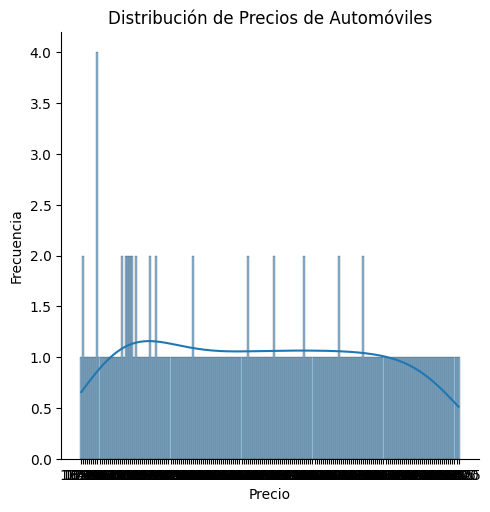

In [ ]:
# @title
# Distribución de la variable 'price'
plt.figure(figsize=(8, 5))
sns.displot(df['price'], kde=True)
plt.title('Distribución de Precios de Automóviles')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')

plt.show()

3.3. Análisis de Variables Numéricas Clave vs. Precio

Visualizamos la relación entre las variables numéricas más predictivas (como el tamaño del motor, la potencia y el consumo) y el precio.

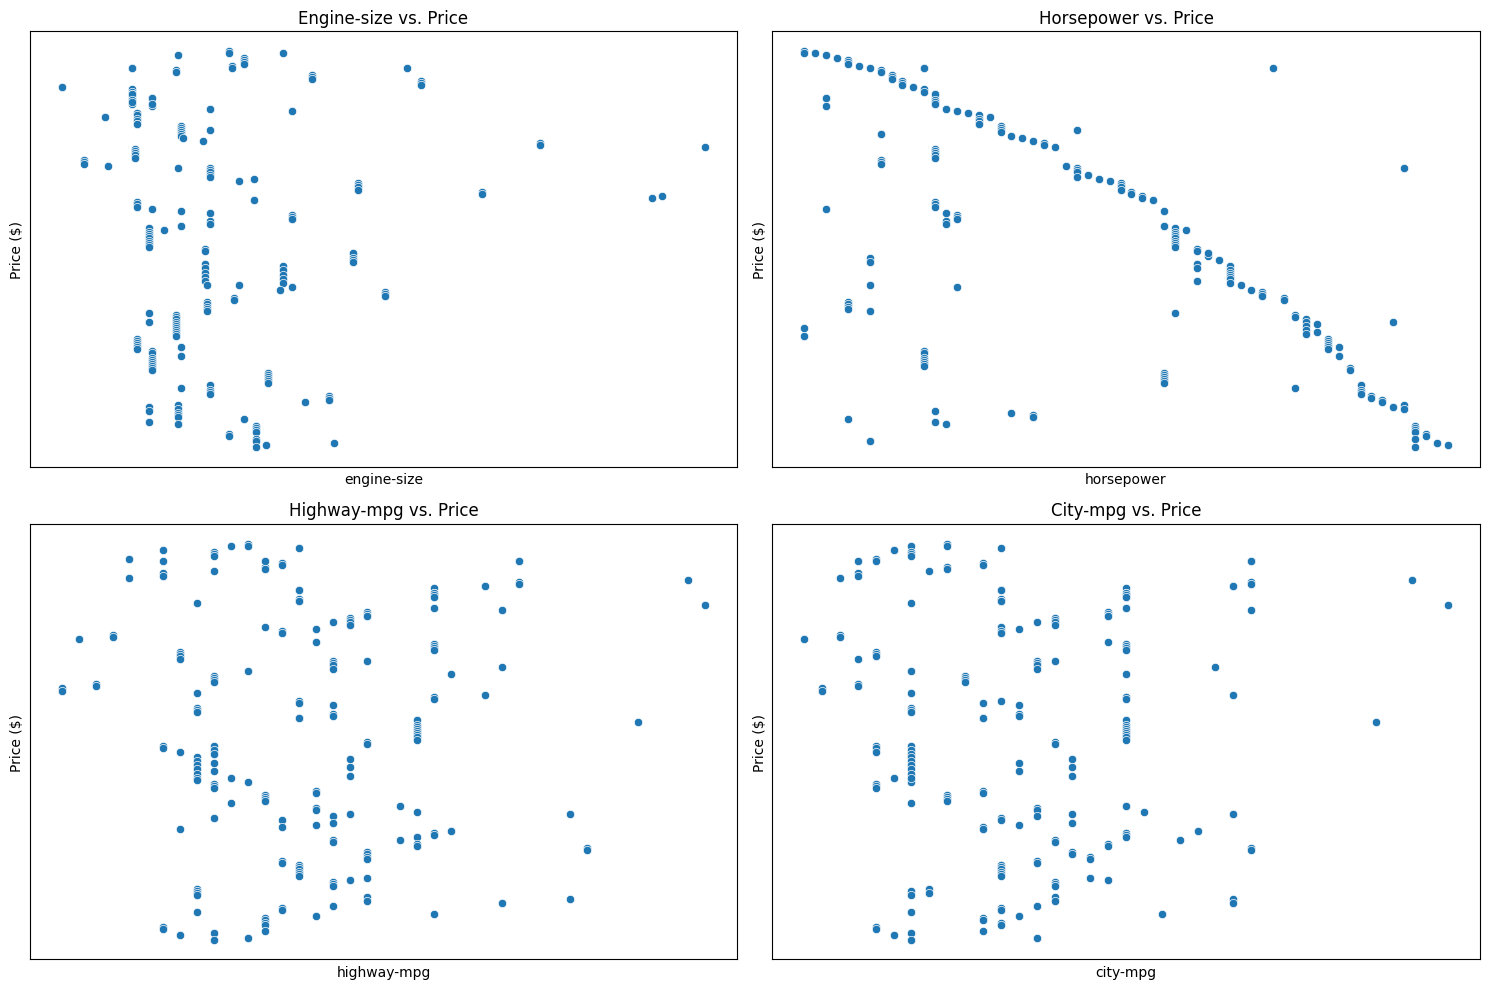

In [ ]:
# Variables numéricas clave
numeric_features = ['engine-size', 'horsepower', 'highway-mpg', 'city-mpg']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numeric_features):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(x=df[feature], y=df['price'])
    plt.title(f'{feature.capitalize()} vs. Price')
    plt.xlabel(feature)
    plt.ylabel('Price ($)')
    plt.xticks([]) # Remove x-axis values
    plt.yticks([]) # Remove y-axis values

plt.tight_layout()
plt.show()

3.4. Correlación entre Variables Numéricas

Un mapa de calor nos ayuda a entender las relaciones de colinealidad entre las características.

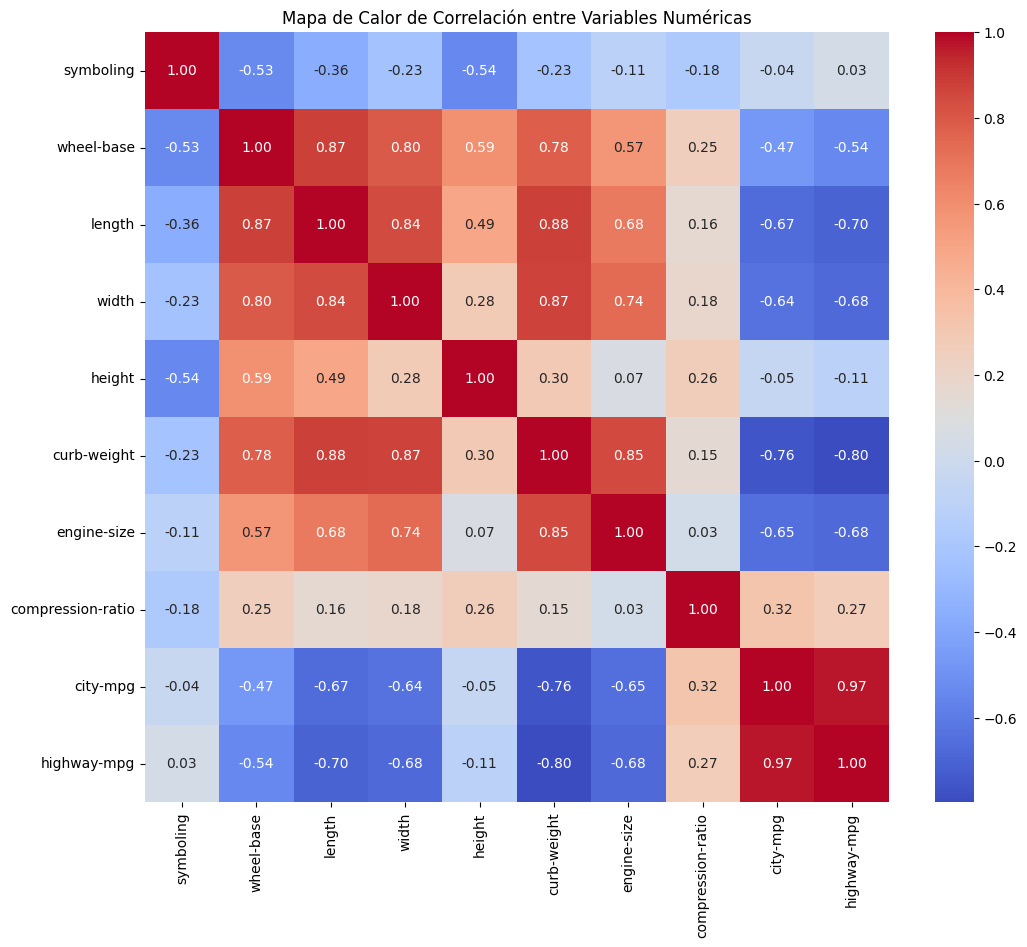

In [ ]:
# Seleccionar solo las columnas numéricas para el mapa de calor
numerical_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 10))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlación entre Variables Numéricas')
plt.show()

3.5. Análisis de Variables Categóricas Clave vs. Precio

Utilizamos diagramas de caja (Box Plots) para ver cómo el precio se distribuye para diferentes categorías (ej. Tipo de combustible, tipo de carrocería).


/tmp/ipython-input-2898208711.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['price'].fillna(df['price'].median(), inplace=True)
/tmp/ipython-input-2898208711.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

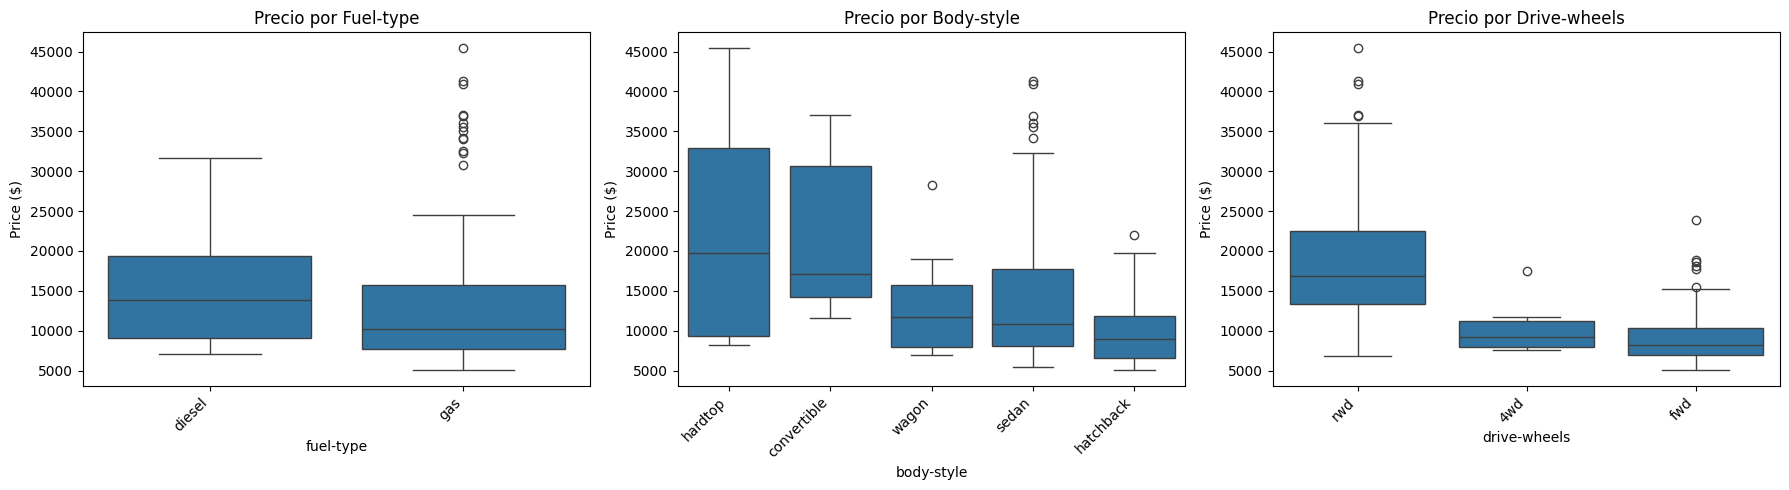

In [ ]:
# Variables categóricas clave
categorical_features = ['fuel-type', 'body-style', 'drive-wheels']

plt.figure(figsize=(18, 5))
for i, feature in enumerate(categorical_features):
    plt.subplot(1, 3, i + 1)
    # Asegurarse de que la columna 'price' sea numérica antes de calcular la mediana
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    df['price'].fillna(df['price'].median(), inplace=True)

    # Ordenar las cajas por precio mediano para una mejor visualización
    order = df.groupby(feature)['price'].median().sort_values(ascending=False).index
    sns.boxplot(x=df[feature], y=df['price'], order=order)
    plt.title(f'Precio por {feature.capitalize()}')
    plt.xlabel(feature)
    plt.ylabel('Price ($)')
    plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor lectura

plt.tight_layout()
plt.show()

Observaciones:

fuel-type: Los coches Diesel (si los hay) pueden tener una distribución de precios diferente a los de Gas.

body-style: Los Hardtop y Convertibles generalmente tienen precios medianos y máximos más altos.

drive-wheels: Los autos con tracción rwd (tracción trasera) suelen tener precios promedio más altos que los fwd (tracción delantera).

4. Preprocesamiento de Datos

La calidad de los datos es clave. Limpiamos, transformamos y preparamos las características para el modelo.

4.1. Limpieza de Valores Errados y Faltantes

En este conjunto de datos, los valores faltantes o erróneos a menudo están marcados con ?. Los reemplazaremos con NaN para poder manejarlos.

In [ ]:
# Reemplazar '?' por NaN
df = df.replace('?', np.nan)

# Convertir columnas a tipo numérico y forzar errores (donde no se pueda convertir) a NaN
cols_to_convert = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Manejo de Valores Faltantes (Imputación con la media para las columnas numéricas)
for col in cols_to_convert:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

# Eliminar filas con NaN en variables categóricas si existen (para este ejemplo, se asume que son mínimas)
df.dropna(inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 203 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          203 non-null    int64  
 1   normalized-losses  203 non-null    float64
 2   make               203 non-null    object 
 3   fuel-type          203 non-null    object 
 4   aspiration         203 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         203 non-null    object 
 7   drive-wheels       203 non-null    object 
 8   engine-location    203 non-null    object 
 9   wheel-base         203 non-null    float64
 10  length             203 non-null    float64
 11  width              203 non-null    float64
 12  height             203 non-null    float64
 13  curb-weight        203 non-null    int64  
 14  engine-type        203 non-null    object 
 15  num-of-cylinders   203 non-null    object 
 16  engine-size        203 non-null

/tmp/ipython-input-2387951633.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


4.2. Separación de Características y Variable Objetivo

Definimos las variables predictoras (X) y la variable a predecir (y).

In [ ]:
# Definir X (features) e y (target)
X = df.drop('price', axis=1)
y = df['price']

# Eliminar columnas irrelevantes para el modelado (e.g., ID, nombre, etc.)
X = X.drop(['make'], axis=1) # 'make' (fabricante) se puede usar, pero lo eliminamos para un ejemplo más simple

# Identificar columnas numéricas y categóricas restantes
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

4.3. Codificación y Escalado (Pipeline de Preprocesamiento)

Utilizamos un ColumnTransformer para aplicar diferentes transformaciones a diferentes tipos de columnas.

In [ ]:
# 1. Pipeline para características numéricas: Escalado (StandardScaler)
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# 2. Pipeline para características categóricas: Codificación One-Hot
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # 'handle_unknown' ignora categorías que no vio en el entrenamiento
])

# Combinar ambos transformadores
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

4.4. División de Datos (Entrenamiento y Prueba)

Dividimos el dataset para entrenar el modelo y luego probar su rendimiento con datos que nunca ha visto.

In [ ]:
# 80% para entrenamiento, 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test: {X_test.shape}")

Tamaño de X_train: (162, 24)
Tamaño de X_test: (41, 24)


5. Entrenamiento del Modelo de Regresión

Utilizaremos un modelo simple de Regresión Lineal encapsulado en un Pipeline para aplicar el preprocesamiento antes del entrenamiento.

In [ ]:
# 1. Definir el modelo
model = LinearRegression()

# 2. Crear el Pipeline completo
# El Pipeline primero aplica el preprocesador (escalado + one-hot) y luego entrena el modelo.
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', model)
])

# 3. Entrenar el modelo
print("Iniciando el entrenamiento...")
full_pipeline.fit(X_train, y_train)
print("Entrenamiento completado.")

Iniciando el entrenamiento...
Entrenamiento completado.


6. Evaluación del Modelo

Evaluamos qué tan bien se desempeña el modelo en el conjunto de prueba (X_test).

6.1. Generación de Predicciones

In [ ]:
# Generar predicciones en el conjunto de prueba
y_pred = full_pipeline.predict(X_test)

6.2. Cálculo de Métricas

Usamos métricas comunes para la regresión:

MAE (Error Absoluto Medio): El error promedio en las predicciones.

RMSE (Raíz del Error Cuadrático Medio): Similar al MAE, pero penaliza más los errores grandes.

R² (Coeficiente de Determinación): Proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes. Un valor cercano a 1 es ideal.

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2_test = r2_score(y_test, y_pred)

# Calcular el R² en el conjunto de entrenamiento
y_train_pred = full_pipeline.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)


print(f"Error Absoluto Medio (MAE): ${mae:,.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): ${rmse:,.2f}")
print(f"Coeficiente de Determinación (R² en Test): {r2_test:.4f}")
print(f"Coeficiente de Determinación (R² en Train): {r2_train:.4f}")

# Comprobar underfitting/overfitting
if r2_train < 0.6: # Umbral arbitrario, ajustar según el problema
    print("\nObservación: El modelo podría estar sufriendo de Underfitting.")
elif r2_train - r2_test > 0.1: # Umbral arbitrario, ajustar según el problema
    print("\nObservación: El modelo podría estar sufriendo de Overfitting.")
else:
    print("\nObservación: El modelo parece tener un buen balance entre Underfitting y Overfitting.")

Error Absoluto Medio (MAE): $3,310.46
Raíz del Error Cuadrático Medio (RMSE): $5,959.82
Coeficiente de Determinación (R² en Test): 0.6192
Coeficiente de Determinación (R² en Train): 0.9445

Observación: El modelo podría estar sufriendo de Overfitting.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

6.3. Visualización de la Evaluación

Comparamos visualmente los valores reales (y_test) con los valores predichos (y_pred).

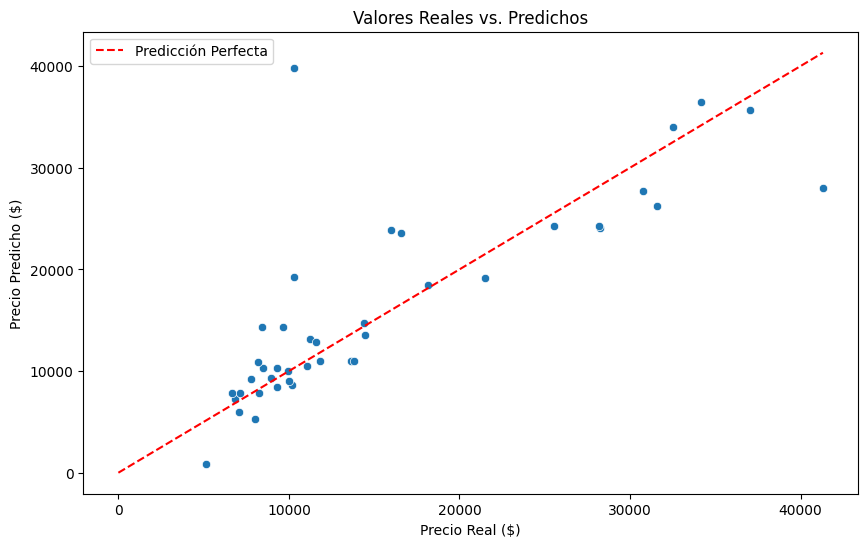

In [ ]:
plt.figure(figsize=(10, 6))
# Gráfico de dispersión (Scatter Plot) de Valores Reales vs. Predichos
sns.scatterplot(x=y_test, y=y_pred)

# Línea de identidad (predicción perfecta)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Predicción Perfecta')

plt.title('Valores Reales vs. Predichos')
plt.xlabel('Precio Real ($)')
plt.ylabel('Precio Predicho ($)')
plt.legend()
plt.show()

7. Generación de Proyecciones (Predicciones)

Una vez que el modelo está entrenado, se puede usar para predecir el precio de nuevos automóviles.

In [ ]:
# **¡IMPORTANTE!** Para una predicción en la vida real, necesitarías una
# *nueva instancia* de datos con todas las columnas de entrada (X)
# (e.g., 'symboling', 'wheel-base', 'engine-size', 'fuel-type', etc.)

# Ejemplo de Proyección: Predecir el precio de los primeros 5 vehículos del conjunto de prueba.

# Obtener las 5 primeras filas de X_test (sin la variable objetivo)
new_data_sample = X_test.head(5)

# Generar la proyección
proyecciones = full_pipeline.predict(new_data_sample)

# Mostrar la comparación (Reales vs. Proyectados)
results_df = pd.DataFrame({
    'Precio Real': y_test.head(5).values,
    'Precio Proyectado': proyecciones.round(2)
})

print("\n--- Proyecciones del Modelo ---")
print(results_df)

# FIN DEL FLUJO DE MACHINE LEARNING


--- Proyecciones del Modelo ---
   Precio Real  Precio Proyectado
0      30760.0           27746.62
1      10295.0           19246.16
2      18150.0           18468.79
3       9959.0            9984.17
4      28248.0           24111.51
